In [26]:
import pandas as pd

data = pd.read_csv('data.csv')
stations = pd.read_csv('station.csv')
stations = stations.rename(columns={'WMO ID': 'wmo_id', 'Latitude': 'lat', 'Longitude': 'lon'})

In [27]:
# Ensure 'wmo_id' is the same type in both DataFrames for merging
data['wmo_id'] = data['wmo_id'].astype(str)
stations['wmo_id'] = stations['wmo_id'].astype(str)

# Perform the Merge (Left Join)
# This keeps all your atmospheric data and attaches the coordinates
df_merged = pd.merge(data, stations, on='wmo_id', how='left')

In [40]:
df_merged.isna().sum()

lvl_type                   0
press                      0
gph                        0
temp                       0
rh                   2005194
wdir                  330527
wspd                  318758
wmo_id                     0
year                       0
month                      0
day                        0
hour                       0
flight_id                  0
City Name                  0
BMKG Station Name          0
lat                        0
lon                        0
dtype: int64

In [155]:
# 1. DROP rows with missing coordinates (lat/lon)
df = df_merged[['wmo_id','lat','lon','gph','press','temp','year','month','day','hour','flight_id']].dropna(subset=['temp', 'press', 'gph'])


In [156]:
# 1. Create the bin identifier (500m steps)
df['alt_bin'] = (df['gph'] // 300) * 300

# 2. Group by Flight and Bin, taking the mean of T and P
df_binned = df.groupby(['flight_id', 'alt_bin']).agg({
    'temp': 'mean',
    'press': 'mean',
    'lat': 'first',
    'lon': 'first',
    'month': 'first',
    'hour': 'first',
    'wmo_id': 'first'
}).reset_index()

# 3. Sort to ensure vertical order for the LSTM
df_binned = df_binned.sort_values(['flight_id', 'alt_bin'])

In [157]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. Ensure flight_id is truly unique (Station ID + Timestamp)
df_train = df_binned.copy()
df_train['flight_id'] = df_train['wmo_id'].astype(str) + "_" + df_train['flight_id'].astype(str)

# 2. Circular Encoding for Month and Hour
df_train['month_sin'] = np.sin(2 * np.pi * df_train['month']/12)
df_train['month_cos'] = np.cos(2 * np.pi * df_train['month']/12)
df_train['hour_sin'] = np.sin(2 * np.pi * df_train['hour']/24)
df_train['hour_cos'] = np.cos(2 * np.pi * df_train['hour']/24)

# 3. Define the features for the LSTM
# We drop the raw time columns now that we have sin/cos versions
features = ['lat', 'lon', 'alt_bin', 'press', 'temp', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos']


print("Final Prepped DF Head:")
print(df_train[['flight_id'] + features])

Final Prepped DF Head:
               flight_id   lat     lon  alt_bin     press       temp  \
0       96743_1955091203 -6.12  106.85      0.0  100650.0  29.700000   
1       96743_1955091203 -6.12  106.85   1500.0   85000.0  17.200000   
2       96743_1955091203 -6.12  106.85   3000.0   70000.0   9.200000   
3       96743_1955091203 -6.12  106.85   5700.0   50000.0  -6.200000   
4       96743_1955091203 -6.12  106.85   7500.0   40000.0 -15.800000   
...                  ...   ...     ...      ...       ...        ...   
665505  96743_2026030712 -6.12  106.85  12300.0   20000.0 -51.700000   
665506  96743_2026030712 -6.12  106.85  14100.0   15000.0 -67.500000   
665507  96935_2026030712 -7.38  112.78  16500.0   10000.0 -83.366667   
665508  97502_2026030712 -0.89  131.29  18300.0    7000.0 -80.300000   
665509  96935_2026030712 -7.38  112.78  18600.0    7000.0 -77.800000   

        month_sin     month_cos      hour_sin  hour_cos  
0            -1.0 -1.836970e-16  7.071068e-01  0.70710

In [158]:
# Apply physical constraints to your binned dataframe
df_train = df_train[
    (df_train['temp'] > -100) & (df_train['temp'] < 50) &
    (df_train['press'] > 500) & (df_train['press'] < 110000)
].copy()

# Remove non-physical altitudes (Indonesia has no depressions below sea level)
df_train = df_train[df_train['alt_bin'] >= 0]

# Remove non-physical pressure/altitude correlations
# (Pressure must decrease as altitude increases)
# Roughly: Sea level ~100k Pa, 5km ~50k Pa, 16km ~10k Pa
df_train = df_train[
    ((df_train['alt_bin'] < 1000) & (df_train['press'] > 80000)) | 
    ((df_train['alt_bin'] >= 1000))
]

# Re-calculate your Min/Max for scaling after this

In [159]:
# Robust Scaling: Fit the scaler on data WITHOUT the extreme outliers
from sklearn.preprocessing import RobustScaler

# Use RobustScaler or clip the data to 1st and 99th percentiles
temp_min, temp_max = df_train['temp'].quantile(0.01), df_train['temp'].quantile(0.99)
press_min, press_max = df_train['press'].quantile(0.01), df_train['press'].quantile(0.99)

df_train = df_train[
    (df_train['temp'].between(temp_min, temp_max)) & 
    (df_train['press'].between(press_min, press_max))
].copy()


In [160]:
def interpolate_flights(df):
    interpolated_frames = []
    
    # Define which columns are static (don't change during the flight)
    static_cols = ['lat', 'lon', 'wmo_id', 'month', 'hour', 
                   'month_sin', 'month_cos', 'hour_sin', 'hour_cos']
    
    for _id, group in df.groupby('flight_id'):
        # 1. Sort and clean duplicates
        group = group.sort_values('alt_bin').drop_duplicates('alt_bin')
        
        # 2. Create the 300m range
        # Note: we use round() to avoid floating point math issues like 299.9999
        min_alt = group['alt_bin'].min()
        max_alt = group['alt_bin'].max()
        full_range = np.arange(min_alt, max_alt + 300, 300)
        
        # 3. Reindex to the new 300m grid
        group = group.set_index('alt_bin').reindex(full_range)
        
        # 4. Handle the Physics (Linear Interpolation)
        # Limit 5 means we only fill gaps up to 1500m (5 * 300m)
        group[['temp', 'press']] = group[['temp', 'press']].interpolate(method='linear', limit=5)
        
        # 5. Handle the Static Features (Broadcasting/Filling)
        group['flight_id'] = _id
        group[static_cols] = group[static_cols].ffill().bfill()
        
        # 6. Final Clean up
        interpolated_frames.append(group.reset_index().rename(columns={'index': 'alt_bin'}).dropna())
        
    return pd.concat(interpolated_frames, ignore_index=True)

df_complete = interpolate_flights(df_train)

In [161]:
print(df_complete)

         alt_bin         flight_id       temp          press   lat     lon  \
0            0.0  96163_1988080900  24.525000  100400.000000  3.91  108.39   
1          300.0  96163_1988080900  22.962500   97175.000000  3.91  108.39   
2          600.0  96163_1988080900  21.400000   93950.000000  3.91  108.39   
3          900.0  96163_1988080900  19.566667   89958.333333  3.91  108.39   
4         1200.0  96163_1988080900  17.733333   85966.666667  3.91  108.39   
...          ...               ...        ...            ...   ...     ...   
2550777  19500.0  97502_2026030312 -76.547059    6058.823529 -0.89  131.29   
2550778  19800.0  97502_2026030312 -75.358824    5823.529412 -0.89  131.29   
2550779  23400.0  97502_2026030312 -61.100000    3000.000000 -0.89  131.29   
2550780  18300.0  97502_2026030412 -80.100000    7000.000000 -0.89  131.29   
2550781  18300.0  97502_2026030712 -80.300000    7000.000000 -0.89  131.29   

         month  hour wmo_id  month_sin     month_cos      hour_

In [162]:
def create_sequences(df, window_size=20):
    X, y = [], []
    
    # Feature columns we are training on
    features = ['alt_bin', 'temp', 'press', 'lat', 'lon', 
                'month_sin', 'month_cos', 'hour_sin', 'hour_cos']
    
    # Group by flight to prevent cross-flight leakage
    for _id, group in df.groupby('flight_id'):
        data = group[features].values
        
        # Only process if the flight is long enough for at least one window
        if len(data) > window_size:
            for i in range(len(data) - window_size):
                # X is the sequence (30 steps)
                # y is the next step (the target we want to predict)
                X.append(data[i : i + window_size])
                y.append(data[i + window_size])
                
    return np.array(X), np.array(y)

# Execute the windowing
X_train, y_train = create_sequences(df_complete, window_size=20)

print(f"X_train shape: {X_train.shape}") # (Samples, 10, 9)
print(f"y_train shape: {y_train.shape}") # (Samples, 9)

X_train shape: (1445671, 20, 9)
y_train shape: (1445671, 9)


In [163]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define Shapes
# Dynamic: 3 features (Alt, Temp, Press) x 20 steps
# Static: 6 features (Lat, Lon, Month_sin, Month_cos, Hour_sin, Hour_cos)
dynamic_shape = (20, 3)
static_shape = (6,)

# --- 1. Dynamic Branch (LSTM) ---
dynamic_input = layers.Input(shape=dynamic_shape, name='dynamic_input')
x1 = layers.LSTM(64, return_sequences=True)(dynamic_input)
x1 = layers.Dropout(0.2)(x1)
x1 = layers.LSTM(32)(x1)

# --- 2. Static Branch (Dense) ---
static_input = layers.Input(shape=static_shape, name='static_input')
x2 = layers.Dense(16, activation='relu')(static_input)

# --- 3. Fusion ---
combined = layers.concatenate([x1, x2])
z = layers.Dense(16, activation='relu')(combined)
output = layers.Dense(2, name='prediction')(z) # Predicting next Temp and Press

model = models.Model(inputs=[dynamic_input, static_input], outputs=output)
model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dynamic_input       │ (None, 20, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_8 (LSTM)       │ (None, 20, 64)    │     17,408 │ dynamic_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 20, 64)    │          0 │ lstm_8[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_9 (LSTM)       │ (None, 32)        │     12,416 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 16)        │        112 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 48)        │          0 │ lstm_9[0][0],     │
│ (Concatenate)       │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 16)        │        784 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction (Dense)  │ (None, 2)         │         34 │ dense_9[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 30,754 (120.13 KB)

 Trainable params: 30,754 (120.13 KB)

 Non-trainable params: 0 (0.00 B)

In [164]:

X_dynamic = X_train[:, :, 0:3]  # Only the first 3 columns
X_static = X_train[:, 0, 3:]    # Take the static values from the first step of each window

# y should be the Temp and Press of the next step
y_target = y_train[:, 1:3]

In [165]:
from sklearn.model_selection import train_test_split

# Split into Training (80%) and Validation (20%)
# Ensure X_dynamic, X_static, and y_target are synchronized
indices = np.arange(X_dynamic.shape[0])
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

# Training sets
X_dyn_train_raw = X_dynamic[train_idx]
X_sta_train_raw = X_static[train_idx]
y_train_raw = y_target[train_idx]

# Validation sets
X_dyn_val_raw = X_dynamic[val_idx]
X_sta_val_raw = X_static[val_idx]
y_val_raw = y_target[val_idx]

In [166]:
# Scaler for Dynamic (Alt, Temp, Press)
# We flatten the 3D to 2D just for fitting
scaler_dyn = MinMaxScaler()
scaler_dyn.fit(X_dyn_train_raw.reshape(-1, 3))

# Scaler for Static (Lat, Lon, Sin/Cos time)
scaler_sta = MinMaxScaler()
scaler_sta.fit(X_sta_train_raw)

# Scaler for Target (Temp, Press) - This makes inverse transform EASY later
scaler_target = MinMaxScaler()
scaler_target.fit(y_train_raw)

MinMaxScaler()

In [167]:
#Apply the scaling
def scale_3d(data, scaler):
    # Reshape 3D -> 2D, transform, then back to 3D
    s = data.shape
    return scaler.transform(data.reshape(-1, s[2])).reshape(s)

# Apply to Dynamic
X_dyn_train = scale_3d(X_dyn_train_raw, scaler_dyn)
X_dyn_val = scale_3d(X_dyn_val_raw, scaler_dyn)

# Apply to Static
X_sta_train = scaler_sta.transform(X_sta_train_raw)
X_sta_val = scaler_sta.transform(X_sta_val_raw)

# Apply to Target
y_train_target = scaler_target.transform(y_train_raw)
y_val_target = scaler_target.transform(y_val_raw)

In [169]:
# Setup Early Stopping
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Start Training
history = model.fit(
    x=[X_dyn_train, X_sta_train],
    y=y_train_target,
    validation_data=([X_dyn_val, X_sta_val], y_val_target),
    epochs=30,         
    batch_size=1024,     
    callbacks=[callback],
    verbose=1
)

Epoch 1/30
1130/1130 ━━━━━━━━━━━━━━━━━━━━ 139s 123ms/step - loss: 5.5017e-04 - val_loss: 4.6074e-04
Epoch 2/30
1130/1130 ━━━━━━━━━━━━━━━━━━━━ 133s 118ms/step - loss: 5.2564e-04 - val_loss: 4.3433e-04
Epoch 3/30
1130/1130 ━━━━━━━━━━━━━━━━━━━━ 152s 134ms/step - loss: 5.0666e-04 - val_loss: 4.3273e-04
Epoch 4/30
1130/1130 ━━━━━━━━━━━━━━━━━━━━ 136s 120ms/step - loss: 4.9291e-04 - val_loss: 4.3425e-04
Epoch 5/30
1130/1130 ━━━━━━━━━━━━━━━━━━━━ 142s 125ms/step - loss: 4.8115e-04 - val_loss: 4.8585e-04
Epoch 6/30
1130/1130 ━━━━━━━━━━━━━━━━━━━━ 147s 130ms/step - loss: 4.6841e-04 - val_loss: 4.3045e-04
Epoch 7/30
1130/1130 ━━━━━━━━━━━━━━━━━━━━ 141s 125ms/step - loss: 4.5583e-04 - val_loss: 4.0323e-04
Epoch 8/30
1130/1130 ━━━━━━━━━━━━━━━━━━━━ 137s 121ms/step - loss: 4.4307e-04 - val_loss: 3.7382e-04
Epoch 9/30
1130/1130 ━━━━━━━━━━━━━━━━━━━━ 132s 116ms/step - loss: 4.1726e-04 - val_loss: 3.4982e-04
Epoch 10/30
1130/1130 ━━━━━━━━━━━━━━━━━━━━ 138s 122ms/step - loss: 3.6743e-04 - val_loss: 2.7704e-04

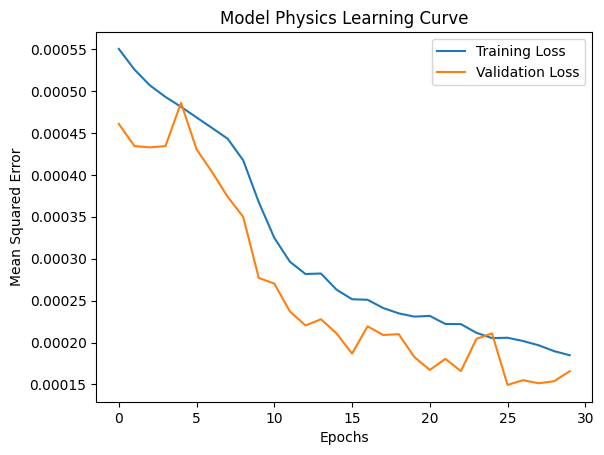

In [170]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Physics Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()

In [171]:
# 1. Predict on the validation set
y_pred_scaled = model.predict([X_dyn_val, X_sta_val])

# 2. Inverse transform back to Celsius and Pascals
# Using the dedicated target scaler we created in the last step
y_pred_real = scaler_target.inverse_transform(y_pred_scaled)
y_actual_real = scaler_target.inverse_transform(y_val_target)

9036/9036 ━━━━━━━━━━━━━━━━━━━━ 45s 5ms/step


In [174]:
# 3. Create a results table with metadata
results_df = pd.DataFrame({
    'flight_id': df_complete.iloc[val_idx]['flight_id'].values,
    'alt_bin': df_complete.iloc[val_idx]['alt_bin'].values,
    'actual_temp': y_actual_real[:, 0],
    'pred_temp': y_pred_real[:, 0],
    'actual_press': y_actual_real[:, 1],
    'pred_press': y_pred_real[:, 1]
})

# 4. Calculate the Absolute Error (Residuals)
results_df['temp_error'] = np.abs(results_df['actual_temp'] - results_df['pred_temp'])
results_df['press_error'] = np.abs(results_df['actual_press'] - results_df['pred_press'])

mae_temp = abs(results_df['temp_error']).mean()
mae_press = abs(results_df['press_error']).mean()
print(f"MAE for Temperature: {mae_temp}")
print(f"MAE for Pressure: {mae_press}")

print(results_df)

MAE for Temperature: 0.5621514557608126
MAE for Pressure: 221.06275743065754
               flight_id  alt_bin  actual_temp  pred_temp  actual_press  \
0       96163_2015093012   3900.0   -80.408333 -80.548225   9500.000000   
1       96163_2007061112  22200.0   -51.100000 -50.492020   2000.000000   
2       96163_2003120400   6600.0   -78.842857 -79.692429   9142.857143   
3       96743_1984082612  15000.0   -71.083333 -70.188812   7317.500000   
4       96163_2017070900   3600.0   -37.214286 -37.170891  26250.000000   
...                  ...      ...          ...        ...           ...   
289130  96743_1979072700   9600.0   -78.814286 -77.136292  11342.857143   
289131  96163_2017022300    900.0   -35.955000 -35.937233  26250.000000   
289132  96163_2000062700  11100.0   -39.090000 -38.755795  26250.000000   
289133  96163_2014032912  14100.0   -72.581111 -72.587929   6000.000000   
289134  96743_1958093012   5700.0   -70.700000 -71.609619   7000.000000   

          pred_press  

In [175]:
# Calculate mean and standard deviation of errors
temp_err_mean = results_df['temp_error'].mean()
temp_err_std = results_df['temp_error'].std()

press_err_mean = results_df['press_error'].mean()
press_err_std = results_df['press_error'].std()

# Define Thresholds (3-Sigma Rule)
# Anything beyond this is statistically 99.7% likely to be an anomaly
threshold_temp = temp_err_mean + (3 * temp_err_std)
threshold_press = press_err_mean + (3 * press_err_std)

print(f"Temperature Anomaly Threshold: {threshold_temp:.2f} °C")
print(f"Pressure Anomaly Threshold: {threshold_press:.2f} Pa")

Temperature Anomaly Threshold: 3.74 °C
Pressure Anomaly Threshold: 1535.31 Pa


In [198]:
# 1. Generate sequences for the entire dataset
# Use the same window_size (20)
# Note: Ensure you use the version of create_sequences that handles flight boundaries!
X_all, y_all = create_sequences(df_train, window_size=20)

# 2. Split into Dynamic (LSTM) and Static (Dense) inputs
# X_all shape is (N_samples, 20, 9)
# Dynamic: alt_bin, temp, press (Indices 0, 1, 2)
X_dyn_all = X_all[:, :, 0:3]

# Static: lat, lon, month_sin, month_cos, hour_sin, hour_cos (Indices 3 to 8)
# We take the value from the first step of the window as it's constant
X_sta_all = X_all[:, 0, 3:]

# 3. Apply Scaling (Use the EXACT scalers from your training phase)
X_dyn_scaled = scale_3d(X_dyn_all, scaler_dyn) # Using your custom 3D scaling function
X_sta_scaled = scaler_sta.transform(X_sta_all)

# 4. Model Prediction
# Use a very large batch_size (4096+) since we aren't calculating gradients
print("Starting inference on 2.5M rows...")
y_pred_scaled_all = model.predict([X_dyn_scaled, X_sta_scaled], batch_size=1024)

# 5. Inverse Transform back to real Physical units (°C and Pa)
y_pred_real_all = scaler_target.inverse_transform(y_pred_scaled_all)

Starting inference on 2.5M rows...
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


In [199]:
# Create a mask to identify which rows in df_complete actually got a prediction
# (The first 20 rows of every flight_id are skipped by the window)
df_valid_targets = df_train.groupby('flight_id').apply(lambda x: x.iloc[20:]).reset_index(drop=True)

# Merge predictions into this dataframe
df_valid_targets['pred_temp'] = y_pred_real_all[:, 0]
df_valid_targets['pred_press'] = y_pred_real_all[:, 1]

# Calculate Absolute Errors
df_valid_targets['temp_error'] = np.abs(df_valid_targets['temp'] - df_valid_targets['pred_temp'])
df_valid_targets['press_error'] = np.abs(df_valid_targets['press'] - df_valid_targets['pred_press'])

print("Inference Complete. Mean Temp Error:", df_valid_targets['temp_error'].mean())
print("Inference Complete. Mean Press Error:", df_valid_targets['press_error'].mean())

Inference Complete. Mean Temp Error: 4.391622706013945
Inference Complete. Mean Press Error: 1190.6071083852096


C:\Users\ahlil\AppData\Local\Temp\ipykernel_26296\683971231.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_valid_targets = df_train.groupby('flight_id').apply(lambda x: x.iloc[20:]).reset_index(drop=True)


In [200]:
print(df_valid_targets)

              flight_id  alt_bin  temp   press   lat     lon  month  hour  \
0      96163_1991092900  20400.0 -60.8  4940.0  3.91  108.39      9     0   
1      96163_1991092900  22200.0 -52.3  3730.0  3.91  108.39      9     0   
2      96163_1991092900  23700.0 -50.5  3000.0  3.91  108.39      9     0   
3      96163_1991092900  24000.0 -49.9  2820.0  3.91  108.39      9     0   
4      96163_1991092900  26400.0 -53.5  2000.0  3.91  108.39      9     0   
...                 ...      ...   ...     ...   ...     ...    ...   ...   
27183  97502_1989021523  20400.0 -63.3  5000.0 -0.89  131.29      2    23   
27184  97502_1989021523  22200.0 -58.5  3780.0 -0.89  131.29      2    23   
27185  97502_1989021523  23700.0 -56.3  3000.0 -0.89  131.29      2    23   
27186  97502_1989021523  24600.0 -54.5  2540.0 -0.89  131.29      2    23   
27187  97502_1989021523  26400.0 -49.1  2000.0 -0.89  131.29      2    23   

      wmo_id  month_sin     month_cos  hour_sin  hour_cos  pred_temp  \
0  

In [203]:
# Count rows per flight and show the top 10
flight_counts = df_train['flight_id'].value_counts()

print("Top 10 Longest Flights (Number of Rows):")
print(flight_counts.head(10))

# To get the ID and count of the single longest flight
longest_flight_id = flight_counts.idxmax()
max_rows = flight_counts.max()

print(f"\nThe flight with the most rows is {longest_flight_id} with {max_rows} rows.")

Top 10 Longest Flights (Number of Rows):
flight_id
97180_1995090612    49
97180_1995051812    48
97180_1995083112    46
97014_1997090812    45
97180_1995052512    44
97180_1995052912    43
96743_2005062900    43
96743_2006031100    43
96743_2006031500    42
96163_1999081800    42
Name: count, dtype: int64

The flight with the most rows is 97180_1995090612 with 49 rows.


<>:11: SyntaxWarning: invalid escape sequence '\c'
<>:11: SyntaxWarning: invalid escape sequence '\c'
C:\Users\ahlil\AppData\Local\Temp\ipykernel_26296\3477217711.py:11: SyntaxWarning: invalid escape sequence '\c'
  ax1.set_xlabel('Temperature ($^\circ$C)')


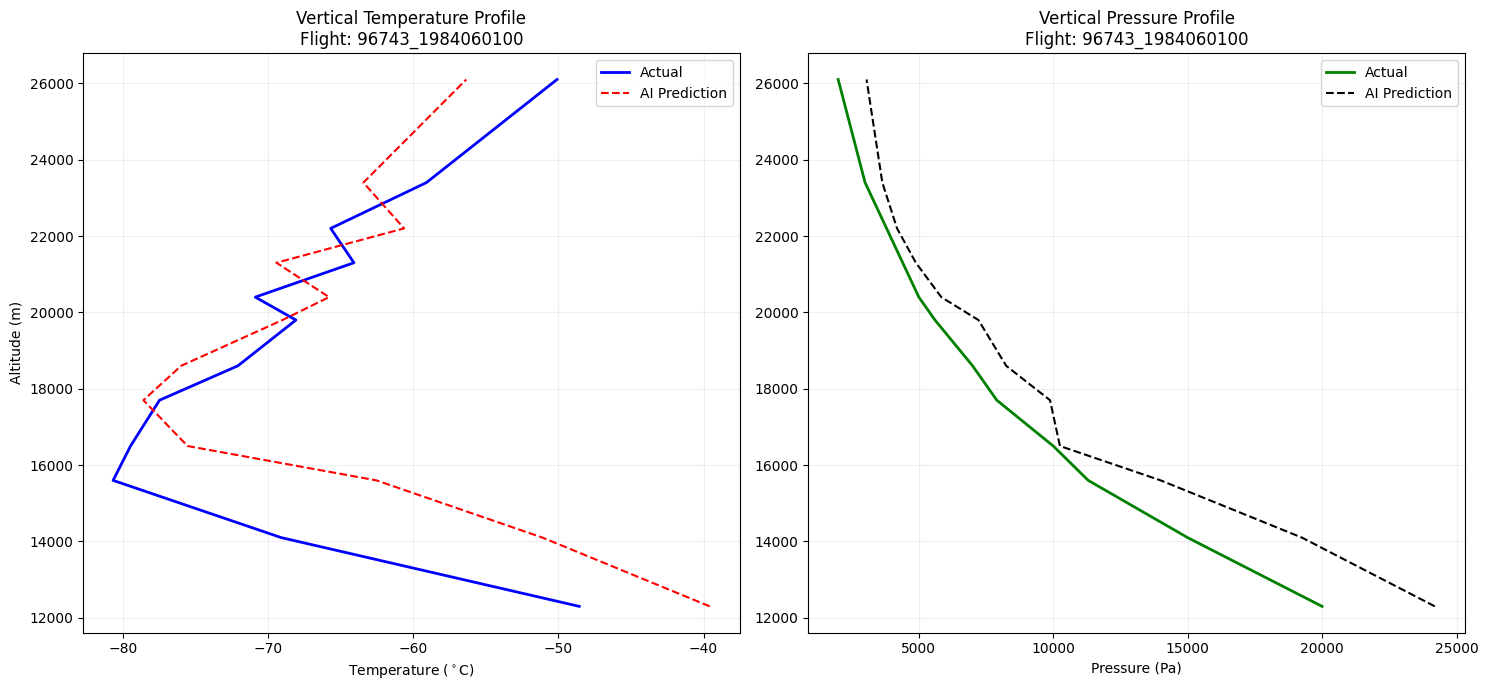

In [207]:
# Select a specific flight
flight_id = "96743_1984060100"
single_flight = df_valid_targets[df_valid_targets['flight_id'] == flight_id].sort_values('alt_bin')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# Temperature Profile
ax1.plot(single_flight['temp'], single_flight['alt_bin'], 'b-', label='Actual', linewidth=2)
ax1.plot(single_flight['pred_temp'], single_flight['alt_bin'], 'r--', label='AI Prediction', linewidth=1.5)
ax1.set_title(f'Vertical Temperature Profile\nFlight: {flight_id}')
ax1.set_xlabel('Temperature ($^\circ$C)')
ax1.set_ylabel('Altitude (m)')
ax1.legend()
ax1.grid(True, alpha=0.2)

# Pressure Profile
ax2.plot(single_flight['press'], single_flight['alt_bin'], 'g-', label='Actual', linewidth=2)
ax2.plot(single_flight['pred_press'], single_flight['alt_bin'], 'k--', label='AI Prediction', linewidth=1.5)
ax2.set_title(f'Vertical Pressure Profile\nFlight: {flight_id}')
ax2.set_xlabel('Pressure (Pa)')
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [205]:
# Create the anomaly masks based on your already calculated thresholds
df_valid_targets['temp_anom'] = df_valid_targets['temp_error'] > threshold_temp
df_valid_targets['press_anom'] = df_valid_targets['press_error'] > threshold_press
df_valid_targets['any_anom'] = df_valid_targets['temp_anom'] | df_valid_targets['press_anom']

# Group by flight_id to see where the errors are clustered
flight_anomaly_report = df_valid_targets.groupby('flight_id').agg(
    total_rows=('alt_bin', 'count'),
    temp_errors=('temp_anom', 'sum'),
    press_errors=('press_anom', 'sum'),
    total_anomalies=('any_anom', 'sum')
).reset_index()

# Calculate the Anomaly Rate (%)
flight_anomaly_report['anomaly_rate_%'] = (flight_anomaly_report['total_anomalies'] / flight_anomaly_report['total_rows']) * 100

# Get the Top 10 most anomalous flights
top_anomalies = flight_anomaly_report.sort_values('total_anomalies', ascending=False).head(10)

print("Top 10 Flights in df_train with the most flagged rows:")
print(top_anomalies[['flight_id', 'total_rows', 'total_anomalies', 'anomaly_rate_%']])

Top 10 Flights in df_train with the most flagged rows:
             flight_id  total_rows  total_anomalies  anomaly_rate_%
4066  97180_1995083112          26               16       61.538462
2993  96743_2006031500          22               14       63.636364
4088  97180_1995102512          22               14       63.636364
4067  97180_1995090612          29               13       44.827586
4022  97180_1995051812          28               13       46.428571
1380  96743_1984060100          12               12      100.000000
2822  96743_2005041800          19               12       63.157895
1282  96743_1984031800          14               12       85.714286
2384  96743_1998082612          18               12       66.666667
1362  96743_1984051900          14               12       85.714286
